In [156]:
! pip install feature_engine==1.8.0 --quiet

In [157]:
!pip install optuna==4.8.0 -q

In [158]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2 -q

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [159]:
# !pip uninstall lightgbm -y
!pip install lightgbm

In [160]:
import torch
print(torch.cuda.is_available()) # Deve retornar True no Colab com GPU ativa

False


In [161]:
import pandas as pd
import numpy as np
import sys
import gc
import random
import os

import unicodedata
import re

import seaborn as sns
import matplotlib.pyplot as plt

import feature_engine
from feature_engine.selection import (
    RecursiveFeatureElimination,
    DropConstantFeatures,
    DropDuplicateFeatures,
)
import optuna

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
import sklearn

import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import torch

import time

import tensorflow as tf

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print("Feature Engine:", feature_engine.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Optuna:", optuna.__version__)
print("XGBoost:", xgb.__version__)
print("LightGBM:", lgb.__version__)
print("Tensorflow", tf.__version__)
print("PyTorch", torch.__version__)

Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2
Feature Engine: 1.8.0
Scikit-Learn: 1.5.2
Optuna: 4.8.0
XGBoost: 3.2.0
LightGBM: 4.6.0
Tensorflow 2.20.0
PyTorch 2.10.0+cpu


In [162]:
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

tf.random.set_seed(SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Garante que as operações na GPU sejam determinísticas (pode reduzir sutilmente a performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [163]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path_main = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [164]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [165]:
path = f'{path_main}/df_feat.csv'
df = get_data_frame(path)

In [166]:
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

In [167]:
df.shape, df.columns

((2245, 66),
 Index(['total_casos', 'score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia',
        'temp_min_dia', 'umidade_dia', 'year', 'month', 'day_week',
        'chuva_acum_7d', 'gravidade_lag_7d', 'chuva_acum_15d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'gravidade_lag_21d',
        'chuva_acum_30d', 'gravidade_lag_30d', 'chuva_acum_45d',
        'gravidade_lag_45d', 'chuva_acum_50d', 'gravidade_lag_50d',
        'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d',
        'casos_mm21d', 'casos_mm30d', 'casos_mm45d', 'casos_mm50d',
        'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_50d', 'temp_max_lag_60d',
        'faixa_chuva', 'faixa_umidade', 'day_month', 'day_month_start',
        'day_month_end', '

In [168]:
def print_nan(df):
    nan_count = df.isna().sum()
    # Filtra apenas onde a contagem é maior que zero
    nan_only = nan_count[nan_count > 0].sort_values(ascending=False)

    if nan_only.empty:
        print("Nenhum valor NaN encontrado!")
    else:
        print("Colunas com valores NaN:")
        print(nan_only)

In [169]:
print_nan(df)

Nenhum valor NaN encontrado!


### Train Test Split

In [170]:
# Separar o df
def train_test_split_by_date(
    data: pd.DataFrame | pd.Series,
    start_date: str,
    split_date: str,
    end_date: str | None = None,
):
    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("data must have a DatetimeIndex")

    # garantir ordem temporal
    data = data.sort_index()

    start_date = pd.to_datetime(start_date)
    split_date = pd.to_datetime(split_date)
    end_date = pd.to_datetime(end_date) if end_date else data.index.max()

    if not (start_date < split_date < end_date):
        raise ValueError("start_date < split_date < end_date is required")

    # 🔑 slicing robusto (não depende da data existir no índice)
    start_pos = data.index.searchsorted(start_date, side="left")
    end_pos = data.index.searchsorted(end_date, side="right")

    data = data.iloc[start_pos:end_pos]

    split_pos = data.index.searchsorted(split_date, side="right")
    train = data.iloc[:split_pos]
    test = data.iloc[split_pos:]

    return train, test

In [171]:
start_date = df.index.min().strftime('%Y-%m-%d')
split_date_test = '2025-12-24' # 60 dias maior lag gerado
split_date_validation = '2025-08-26' # 60 dias
end_date = df.index.max().strftime('%Y-%m-%d')

start_date, split_date_validation, split_date_test, end_date

('2020-03-01', '2025-08-26', '2025-12-24', '2026-04-23')

In [172]:
df_train_temp, df_test = train_test_split_by_date(df, start_date, split_date_test, end_date)

In [173]:
df_train, df_val = train_test_split_by_date(df_train_temp, start_date, split_date_validation, split_date_test)

In [174]:
df_train.shape, df_train.index.unique()

((2005, 66),
 DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None))

In [175]:
df_val.shape, df_val.index.unique()

((120, 66),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [176]:
df_test.shape, df_test.index.unique()

((120, 66),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28',
                '2025-12-29', '2025-12-30', '2025-12-31', '2026-01-01',
                '2026-01-02', '2026-01-03',
                ...
                '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
                '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
                '2026-04-22', '2026-04-23'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [177]:
df_train.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,...,2005.000000,2.005000e+03,2005.000000,2.005000e+03,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2.005000e+03
mean,44.942643,11.634130,30.729394,11.804140,30.199594,18.566284,78.124558,2022.415960,6.426434,2.999002,...,-0.000062,2.698475e-04,0.000360,-1.735400e-04,-0.001930,0.001402,0.001745,0.057908,-0.001244,7.505943e-05
std,129.641138,0.274246,8.451706,33.359878,4.177824,3.094147,7.382627,1.612868,3.344522,2.001745,...,0.707411,7.071557e-01,0.707530,7.070360e-01,0.707053,0.707509,0.706841,0.705349,0.706845,7.077203e-01
min,0.000000,9.000000,0.000000,0.000000,18.700000,8.300000,39.593750,2020.000000,1.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000,-0.994522,-0.999963,-0.999991,-0.999963,-9.999907e-01
25%,3.000000,11.517241,26.666667,0.000000,27.100000,16.400000,73.958333,2021.000000,4.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-0.669131,-0.743145,-0.708627,-0.648630,-0.708627,-7.055836e-01
50%,11.000000,11.625000,30.363636,0.200000,30.200000,19.000000,78.468750,2022.000000,6.000000,3.000000,...,-0.222521,-4.311252e-14,-0.222521,-6.073010e-14,-0.104528,0.000000,0.004304,0.128748,0.004304,2.572996e-15
75%,35.000000,11.765957,33.924781,6.200000,33.300000,21.000000,83.171875,2024.000000,9.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,0.669131,0.743145,0.702527,0.752667,0.702527,7.055836e-01
max,1501.000000,12.000000,68.000000,520.600000,42.500000,25.400000,95.359375,2025.000000,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000,0.994522,1.000000,0.999991,1.000000,9.999907e-01


In [178]:
df_val.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,120.000000,120.000000,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,7.366667,11.573481,28.250134,8.280000,30.158333,18.225000,77.165972,2025.0,10.316667,2.991667,...,0.005196,-6.515262e-03,-0.001854,8.124399e-03,-1.580911e-16,-2.914335e-17,-0.462306,-0.691084,-0.162612,0.393777
std,2.857787,0.179567,6.356627,18.324496,4.261762,2.414426,8.187556,0.0,1.173828,2.002082,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.454632,0.323388,0.741514,0.524911
min,2.000000,11.142857,14.305556,0.000000,21.500000,12.100000,51.916667,2025.0,8.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,-0.999963,-0.999991,-0.999963,-0.763889
25%,5.000000,11.500000,24.809524,0.000000,27.175000,16.825000,72.373698,2025.0,9.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,-0.891957,-0.966289,-0.867432,0.023667
50%,7.000000,11.563492,27.734848,0.200000,29.850000,18.400000,78.645833,2025.0,10.000000,3.000000,...,-0.222521,-1.724402e-13,-0.222521,-2.429798e-13,5.342948e-15,-1.225080e-14,-0.555997,-0.831140,-0.381633,0.512367
75%,9.000000,11.675000,31.664773,8.200000,32.900000,19.825000,82.998698,2025.0,11.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,-0.077384,-0.452060,0.591195,0.868519
max,16.000000,12.000000,52.166667,134.400000,40.000000,22.800000,95.046875,2025.0,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,0.421101,0.043022,0.999852,0.999991


In [179]:
df_test.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,10.550000,11.592108,32.377215,23.183333,32.079583,21.496667,82.836634,2025.941667,2.966667,3.0,...,0.005196,6.515262e-03,-0.001854,-8.124399e-03,2.368476e-16,-4.584296e-16,0.827735,-0.078603,0.418417,-0.080191
std,5.327667,0.223171,7.406475,38.192116,3.607849,1.136184,8.548816,0.235355,2.496833,2.0,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.155771,0.535728,0.482546,0.769756
min,0.000000,11.000000,10.000000,0.000000,22.900000,17.500000,56.947917,2025.000000,1.000000,0.0,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,0.436651,-0.899631,-0.618671,-0.999917
25%,6.000000,11.491667,27.866667,0.000000,29.600000,21.100000,77.618490,2026.000000,1.000000,1.0,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,0.714673,-0.570226,0.021516,-0.866330
50%,10.000000,11.600000,31.538462,10.000000,31.750000,21.300000,84.578125,2026.000000,3.000000,3.0,...,-0.222521,-1.253939e-13,-0.222521,-2.057332e-13,1.219858e-14,-5.390303e-15,0.869589,-0.094533,0.512371,-0.188199
75%,14.000000,11.750000,36.000000,27.800000,35.025000,22.300000,91.055990,2026.000000,3.250000,5.0,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,0.966848,0.405414,0.869589,0.741139
max,25.000000,12.000000,62.666667,210.400000,40.800000,24.200000,96.015625,2026.000000,12.000000,6.0,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,1.000000,0.801361,1.000000,0.999917


In [180]:
print(f"Validação: {df_val.index.min()} até {df_val.index.max()} (Tamanho: {len(df_val)})")
print(f"Teste: {df_test.index.min()} até {df_test.index.max()} (Tamanho: {len(df_test)})")
print("Val e Test são iguais?", df_val.equals(df_test))

Validação: 2025-08-27 00:00:00 até 2025-12-24 00:00:00 (Tamanho: 120)
Teste: 2025-12-25 00:00:00 até 2026-04-23 00:00:00 (Tamanho: 120)
Val e Test são iguais? False


### Split

In [181]:
def split_target(df: pd.DataFrame, columns_target: str):
    y = df[columns_target]
    X = df.drop(columns=[columns_target])

    return X, y

In [182]:
column_target = 'total_casos'

In [183]:
X_train, y_train = split_target(df_train, column_target)
X_val, y_val = split_target(df_val, column_target)
X_test, y_test = split_target(df_test, column_target)

In [184]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
X_test.shape, y_test.shape

(2005, 65) (2005,)
(120, 65) (120,)


((120, 65), (120,))

In [185]:
y_train.isna().sum().sum(), y_val.isna().sum().sum(), y_test.isna().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [186]:
X_train.index, X_val.index, X_test.index

(DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-

# Scaler

In [187]:
X_train.columns

Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
       'umidade_dia', 'year', 'month', 'day_week', 'chuva_acum_7d',
       'gravidade_lag_7d', 'chuva_acum_15d', 'gravidade_lag_15d',
       'chuva_acum_21d', 'gravidade_lag_21d', 'chuva_acum_30d',
       'gravidade_lag_30d', 'chuva_acum_45d', 'gravidade_lag_45d',
       'chuva_acum_50d', 'gravidade_lag_50d', 'chuva_acum_60d',
       'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d', 'casos_mm21d',
       'casos_mm30d', 'casos_mm45d', 'casos_mm50d', 'casos_mm60d',
       'temp_min_lag_7d', 'temp_min_lag_15d', 'temp_min_lag_21d',
       'temp_min_lag_30d', 'temp_min_lag_45d', 'temp_min_lag_50d',
       'temp_min_lag_60d', 'temp_max_lag_7d', 'temp_max_lag_15d',
       'temp_max_lag_21d', 'temp_max_lag_30d', 'temp_max_lag_45d',
       'temp_max_lag_50d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
       'day_month', 'day_month_start', 'day_month_end', 'day_quarter_start',
       'day_quarter_end', 'day

In [188]:
fourier = X_train.filter(like='ciclo')
cols_fourier = fourier.columns.to_list()
cols_fourier

['ciclos_fourier_cos_p7_k1',
 'ciclos_fourier_sin_p7_k1',
 'ciclos_fourier_cos_p7_k2',
 'ciclos_fourier_sin_p7_k2',
 'ciclos_fourier_cos_p7_k3',
 'ciclos_fourier_sin_p7_k3',
 'ciclos_fourier_cos_p30_k1',
 'ciclos_fourier_sin_p30_k1',
 'ciclos_fourier_cos_p365_k1',
 'ciclos_fourier_sin_p365_k1',
 'ciclos_fourier_cos_p365_k2',
 'ciclos_fourier_sin_p365_k2']

In [189]:
X_train_fourier = X_train[cols_fourier]
X_val_fourier = X_val[cols_fourier]
X_test_fourier = X_test[cols_fourier]
X_test_fourier

,ciclos_fourier_cos_p7_k1,ciclos_fourier_sin_p7_k1,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,
2025-12-25,-0.900969,-4.338837e-01,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.222521,-9.749279e-01,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,0.623490,-7.818315e-01,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,1.000000,3.922831e-14,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-19,1.000000,-7.837740e-14,1.000000,-1.567548e-13,1.000000,2.196152e-13,-0.500000,-0.866025,0.651899,0.758306,-0.150055,0.988678
2026-04-20,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,-0.309017,-0.951057,0.638749,0.769415,-0.183998,0.982927
2026-04-21,-0.222521,9.749279e-01,-0.900969,-4.338837e-01,0.623490,-7.818315e-01,-0.104528,-0.994522,0.625411,0.780296,-0.217723,0.976011


In [190]:
X_train_s = X_train.drop(columns=cols_fourier)
X_val_s = X_val.drop(columns=cols_fourier)
X_test_s = X_test.drop(columns=cols_fourier)

In [191]:
X_train_s.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2005 entries, 2020-03-01 to 2025-08-26
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   score_gravidade    2005 non-null   float64
 1   idade              2005 non-null   float64
 2   chuva_dia          2005 non-null   float64
 3   temp_max_dia       2005 non-null   float64
 4   temp_min_dia       2005 non-null   float64
 5   umidade_dia        2005 non-null   float64
 6   year               2005 non-null   int64  
 7   month              2005 non-null   int64  
 8   day_week           2005 non-null   int64  
 9   chuva_acum_7d      2005 non-null   float64
 10  gravidade_lag_7d   2005 non-null   float64
 11  chuva_acum_15d     2005 non-null   float64
 12  gravidade_lag_15d  2005 non-null   float64
 13  chuva_acum_21d     2005 non-null   float64
 14  gravidade_lag_21d  2005 non-null   float64
 15  chuva_acum_30d     2005 non-null   float64
 16  gravid

In [192]:
def encode_categorical_columns(df):
    df_encoded = df.copy()
    cat_cols = df_encoded.select_dtypes(include=['category', 'object']).columns

    for col in cat_cols:
        print(f"Transformando a coluna: {col}")
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

    return df_encoded

In [193]:
X_train_s = encode_categorical_columns(X_train_s)
X_val_s = encode_categorical_columns(X_val_s)
X_test_s = encode_categorical_columns(X_test_s)

Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade


In [194]:
scaler = StandardScaler()

In [195]:
X_train_scaled = scaler.fit_transform(X_train_s)
X_val_scaled = scaler.transform(X_val_s)
X_test_scaled = scaler.transform(X_test_s)

In [196]:
X_train_scaled_df = pd.DataFrame(X_train_scaled,
                                 columns=X_train_s.columns,
                                 index=X_train_s.index)

X_val_scaled_df = pd.DataFrame(X_val_scaled,
                                 columns=X_val_s.columns,
                                 index=X_val_s.index)

X_test_scaled_df = pd.DataFrame(X_test_scaled,
                                 columns=X_test_s.columns,
                                 index=X_test_s.index)

X_train_scaled_df

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,temp_max_lag_60d,faixa_chuva,faixa_umidade,day_month,day_month_start,day_month_end,day_quarter_start,day_quarter_end,day_year_start,day_year_end
data,,,,,,,,,,,,,,,,,,,,,
2020-03-01,0.813390,-0.441369,15.255535,-1.436415,0.883732,1.937805,-1.498302,-1.024747,1.499564,4.710811,...,1.742544,0.499203,-1.369086,-1.672869,5.420220,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-02,0.118672,0.071475,1.403109,-1.460357,0.334171,1.731752,-1.498302,-1.024747,-1.498567,5.221635,...,0.488740,0.499203,-1.369086,-1.559105,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-03,0.773310,0.059337,0.029859,-0.550566,0.431152,0.932944,-1.498302,-1.024747,-0.998879,5.287261,...,-0.282832,0.499203,-1.369086,-1.445341,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-04,-0.124480,-1.104123,-0.263980,-0.694217,0.786751,0.615396,-1.498302,-1.024747,-0.499190,5.281940,...,-0.186385,0.499203,1.338922,-1.331577,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-05,0.339718,0.128857,-0.233996,-0.311147,-0.312372,0.175064,-1.498302,-1.024747,0.000498,4.840291,...,-0.138162,0.499203,1.338922,-1.217813,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-22,0.929176,-0.721900,-0.353931,0.598644,-0.829607,-0.166476,1.602540,0.470608,0.500187,-0.713138,...,0.874526,-0.392072,-0.466417,0.716174,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-23,-1.097085,0.515284,-0.353931,1.125366,-1.088224,-2.856456,1.602540,0.470608,0.999876,-0.734422,...,-1.006180,-0.392072,0.436253,0.829938,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-24,-0.286581,-0.572868,-0.353931,-0.311147,-0.635644,-0.558824,1.602540,0.470608,1.499564,-0.734422,...,-1.850087,-0.392072,-0.466417,0.943702,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05


In [197]:
X_train_scaled = pd.concat([X_train_scaled_df, X_train_fourier], axis=1)
X_val_scaled = pd.concat([X_val_scaled_df, X_val_fourier], axis=1)
X_test_scaled = pd.concat([X_test_scaled_df, X_test_fourier], axis=1)

In [198]:
X_train_scaled.shape, X_train.shape

((2005, 65), (2005, 65))

In [199]:
X_val_scaled.shape, X_val.shape

((120, 65), (120, 65))

In [200]:
X_test_scaled.shape, X_test.shape

((120, 65), (120, 65))

In [201]:
X_test_scaled.head()

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,,,,,,,,,,
2025-12-25,-0.124480,0.387072,-0.353931,2.106983,1.110023,-1.153696,1.60254,1.666892,0.000498,-0.562374,...,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.749726,-0.397693,-0.353931,1.771796,0.883732,-0.496726,1.60254,1.666892,0.500187,-0.729101,...,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,1.334428,0.742119,-0.353931,1.269017,0.754424,-0.253978,1.60254,1.666892,0.999876,-0.734422,...,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,-0.124480,0.718449,-0.353931,1.556319,1.142350,-0.776167,1.60254,1.666892,1.499564,-0.734422,...,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,-2.312842,-1.743206,-0.353931,1.292959,0.819078,-0.641386,1.60254,1.666892,-1.498567,-0.734422,...,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142


In [202]:
print_nan(X_train_scaled)
print_nan(X_val_scaled)
print_nan(X_test_scaled)

Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!


# Feature Selection

In [203]:
def feature_selection(X_train, y_train, X_test, model, scoring='neg_root_mean_squared_error', cv=3, threshold=0.001):
    """
    Executa feature selection usando RecursiveFeatureElimination com o modelo cru.
    """
    estimator = clone(model)

    feat_selector = RecursiveFeatureElimination(
        variables=None,
        estimator=estimator,
        scoring=scoring,
        threshold=threshold,
        cv=cv,
    )

    feat_selector.fit(X_train.copy(), y_train)
    X_train_fs = feat_selector.transform(X_train.copy())
    X_test_fs = feat_selector.transform(X_test.copy())

    return X_train_fs, X_test_fs, feat_selector

# Hyperparam Optimization

In [204]:
import plotly.io as pio # PLOT Optuna
pio.renderers.default = "colab" # ou "colab" se estiver no Google Colab

In [205]:
# imports necessários para o pruning
# import xgboost as xgb
# import lightgbm as lgb
# from sklearn.metrics import mean_squared_error

def _train_with_pruning(trial, X, y, tscv, model_name, params):
    """
    Executa a validação cruzada manual permitindo que o Optuna pode
    hiperparâmetros ruins baseando-se no desempenho médio dos folds.
    """
    # Removemos n_estimators dos parâmetros porque quem controla o loop de árvores
    # são as funções xgb.train e lgb.train através do num_boost_round
    num_boost_round = params.pop("n_estimators", 500)

    # Criamos listas para monitorar os scores intermediários de cada rodada/árvore
    # para podermos tirar a média entre os folds
    fold_scores_per_round = []

    # Loop manual pelos folds de Séries Temporais
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        if model_name == 'XGBoost':
            # Converte dados para a estrutura interna do XGBoost
            dtrain = xgb.DMatrix(X_tr, label=y_tr)
            dval = xgb.DMatrix(X_va, label=y_va)

            # Criamos um dicionário local para capturar o histórico do fold atual
            evals_result = {}
            xgb.train(
                params,
                dtrain,
                num_boost_round=num_boost_round,
                evals=[(dval, 'val')],
                evals_result=evals_result,
                verbose_eval=False
            )
            # O XGBoost avalia como RMSE nativamente se configurado, ou extraímos via MSE
            # Garantimos o cálculo do RMSE para cada iteração (árvore) deste fold
            preds_history = evals_result['val']['rmse'] if 'rmse' in evals_result['val'] else np.sqrt(evals_result['val']['rmse'])
            fold_scores_per_round.append(preds_history)

        elif model_name == 'LightGBM':
            # Converte dados para a estrutura interna do LightGBM
            train_data = lgb.Dataset(X_tr, label=y_tr)
            val_data = lgb.Dataset(X_va, label=y_va, reference=train_data)

            evals_result = {}
            lgb.train(
                params,
                train_data,
                num_boost_round=num_boost_round,
                valid_sets=[val_data],
                callbacks=[lgb.record_evaluation(evals_result)],
            )
            # Extrai o histórico da métrica definida no dicionário
            metric_key = list(evals_result['valid_0'].keys())[0]
            preds_history = evals_result['valid_0'][metric_key]

            # Se a métrica do LightGBM for MSE (l2), aplica a raiz quadrada para virar RMSE
            if metric_key in ['l2', 'rmse']:
                preds_history = np.sqrt(preds_history) if metric_key == 'l2' else preds_history

            fold_scores_per_round.append(preds_history)

        # --- Mecanismo de Poda Intermediária (Pruning) ---
        # A cada passo (árvore) do fold atual, se os folds anteriores já completaram esse passo,
        # nós reportamos a média parcial para o Optuna avaliar se vale a pena continuar o trial.
        current_step = len(fold_scores_per_round[-1]) - 1

        # Tiramos a média dos resultados deste passo até o fold atual
        current_step_score = np.mean([f[current_step] for f in fold_scores_per_round if len(f) > current_step])

        # Reporta o progresso combinando o fold atual e o step da árvore
        trial.report(current_step_score, step=fold)

        # Se o Optuna notar que a média desse conjunto de parâmetros está bizarra de ruim, ele corta aqui
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Retorna o RMSE médio final do último step (todas as árvores treinadas em todos os folds)
    final_score = np.mean([f[-1] for f in fold_scores_per_round])
    return final_score

In [206]:
def optimize_model(X_train, y_train, model_name='XGBoost', n_trials=50, n_splits=10,
                   prune=True, n_startup_trials=5, n_warmup_steps=1, random_state=42):
    """
    Realiza hyperparameter optimization usando Optuna com suporte opcional a Pruning
    para modelos de Gradient Boosting em Séries Temporais.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        if model_name == 'XGBoost':
            params = {
                "n_estimators": trial.suggest_int('n_estimators', 100, 1000),
                "max_depth": trial.suggest_int('max_depth', 3, 10),
                "learning_rate": trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
                "subsample": trial.suggest_float('subsample', 0.5, 1.0),
                "colsample_bytree": trial.suggest_float('colsample_bytree', 0.4, 1.0),
                "gamma": trial.suggest_float('gamma', 1e-8, 1.0, log=True),
                "n_jobs": -1,
                "random_state": random_state
            }

            # Configurações específicas necessárias apenas se o Pruning estiver ativo
            if prune:
                params["eval_metric"] = "rmse"

            if torch.cuda.is_available():
                gpu = {"device": "cuda", "tree_method": "hist"}
                params = {**gpu, **params}

        elif model_name == 'LightGBM':
            params = {
                "n_estimators": trial.suggest_int('n_estimators', 100, 1000),
                "learning_rate": trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
                "num_leaves": trial.suggest_int('num_leaves', 20, 150),
                "max_depth": trial.suggest_int('max_depth', 3, 12),
                "min_child_samples": trial.suggest_int('min_child_samples', 5, 100),
                "subsample": trial.suggest_float('subsample', 0.5, 1.0),
                "colsample_bytree": trial.suggest_float('colsample_bytree', 0.5, 1.0),
                "reg_alpha": trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                "reg_lambda": trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                "n_jobs": -1,
                "random_state": random_state,
                "verbose": -1
            }

            # Configurações específicas necessárias apenas se o Pruning estiver ativo
            if prune:
                params["metric"] = "rmse"

            if torch.cuda.is_available():
                gpu = {"device": "gpu", "gpu_platform_id": 0, "gpu_device_id": 0}
                params = {**gpu, **params}
        else:
            raise ValueError(f'Model {model_name} não suportado.')

        # ---- FLUXO COM PRUNING ----
        if prune:
            rmse_medio = _train_with_pruning(trial, X_train, y_train, tscv, model_name, params)
            return rmse_medio

        # ---- FLUXO NORMAL (MÉTODO ANTERIOR) ----
        else:
            if model_name == 'XGBoost':
                model = XGBRegressor(**params)
            elif model_name == 'LightGBM':
                model = LGBMRegressor(**params)

            scores = cross_val_score(
                model, X_train, y_train,
                cv=tscv,
                scoring=make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
                n_jobs=-1
            )
            return np.mean(scores)

    # ---- CONFIGURAÇÃO DO ESTUDO OPTUNA ----
    if prune:
        # Se prune for True, define o pruner para cortar trials ruins precocemente
        pruner = optuna.pruners.MedianPruner(
            n_startup_trials=n_startup_trials,
            n_warmup_steps=n_warmup_steps
        )
        study = optuna.create_study(direction='minimize', pruner=pruner)
    else:
        # Se prune for False, roda o fluxo clássico sem descartar rodadas no meio
        study = optuna.create_study(direction='minimize')

    study.optimize(objective, n_trials=n_trials)

    return study.best_params, study

# Forecasting

In [207]:
# É uma previsão por quantil (Quantile Forecasting),
# que é uma forma direta de previsão probabilística.
# Uma previsão determinística te dá apenas um número (a média ou a mediana).
# Uma previsão probabilística busca mapear a distribuição da incerteza do futuro.
# Existem duas formas principais de fazer isso:Paramétrica: O modelo assume uma distribuição
# (ex: Normal) e prevê a média mu e o desvio padrão sigma.
# Não-paramétrica (Quantílica): O modelo não assume formato de distribuição nenhum.
# Você treina o algoritmo diretamente para chutar valores que deixam uma porcentagem
# específica dos dados abaixo dele. É exatamente o que faremos aqui: ao pedir o quantil 0.05 e 0.95,
# estamos criando uma banda que cobre 90% dos cenários prováveis.

In [208]:
from lightgbm import early_stopping

def _find_best_estimators_temporal(X_train_fs, y_train, model_name, model_map, best_params, n_splits):
    """
    Função auxiliar interna para calibrar o n_estimators ideal usando TimeSeriesSplit
    focando na perda quantílica (mediana / quantil 0.50).
    """
    tscv_interno = TimeSeriesSplit(n_splits=n_splits)
    best_iteration_list = []

    for train_idx, val_idx in tscv_interno.split(X_train_fs):
        X_tr_int = X_train_fs.iloc[train_idx] if hasattr(X_train_fs, "iloc") else X_train_fs[train_idx]
        y_tr_int = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
        X_va_int = X_train_fs.iloc[val_idx] if hasattr(X_train_fs, "iloc") else X_train_fs[val_idx]
        y_va_int = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

        params_tmp = best_params.copy()

        if model_name == 'XGBoost':
            # --- CORREÇÃO AQUI: 'reg:quantileerror' ---
            params_tmp.update({"objective": "reg:quantileerror", "quantile_alpha": 0.50})
            model_tmp = model_map[model_name](**params_tmp)
            model_tmp.set_params(early_stopping_rounds=50, eval_metric="quantile")
            model_tmp.fit(X_tr_int, y_tr_int, eval_set=[(X_va_int, y_va_int)], verbose=False)
            best_iteration_list.append(model_tmp.best_iteration)

        elif model_name == 'LightGBM':
            params_tmp.update({"objective": "quantile", "alpha": 0.50})
            model_tmp = model_map[model_name](**params_tmp)
            model_tmp.set_params(metric="quantile")
            model_tmp.fit(X_tr_int, y_tr_int, eval_set=[(X_va_int, y_va_int)],
                          callbacks=[early_stopping(stopping_rounds=50, verbose=False)])
            best_iteration_list.append(model_tmp.best_iteration_)

    n_estimators_otimizado = int(np.mean(best_iteration_list))

    if n_estimators_otimizado <= 0:
        return best_params.get("n_estimators", 100)

    return n_estimators_otimizado

In [209]:
def forecasting(
      X_train, y_train, X_val, model_name,
      n_trials=10, n_splits=15, random_state=42,
      n_startup_trials=5, n_warmup_steps=1,
      prune=True, early_stop=True,
      low_quantile=0.05, high_quantile=0.95
    ):
  """
  Executa o fluxo completo de previsão quantílica (probabilística):
  Retorna um dicionário contendo y_pred (mediana), y_lower (quantil inferior) e y_upper (quantil superior).
  """
  X_train_ = X_train.copy()
  X_val_ = X_val.copy()
  y_train_ = y_train.copy()

  # ---- Hyperparameter tuning ----
  best_params, study = optimize_model(X_train_, y_train_,
                                      model_name=model_name,
                                      n_trials=n_trials,
                                      n_splits=n_splits,
                                      random_state=random_state,
                                      prune=prune,
                                      n_startup_trials=n_startup_trials,
                                      n_warmup_steps=n_warmup_steps
                                      )
  if best_params is None:
      best_params = {}

  # ---- Criação do mapeamento de modelos ----
  model_map = {
      'XGBoost': XGBRegressor,
      'LightGBM': LGBMRegressor
  }

  if model_name not in model_map:
      raise ValueError(f"Modelo {model_name} não suportado.")

  # Modelo cru para seleção de features
  model_raw = model_map[model_name]()

  # ---- Feature selection com modelo cru ----
  X_train_fs, X_val_fs, feat_selected = feature_selection(
      X_train_, y_train_, X_val_, model_raw, scoring='neg_root_mean_squared_error', cv=5, threshold=0.001
  )

  # ---- VERIFICAÇÃO DO EARLY STOPPING ----
  if early_stop:
      n_estimators_otimizado = _find_best_estimators_temporal(
          X_train_fs, y_train_, model_name, model_map, best_params, n_splits
      )
      best_params["n_estimators"] = n_estimators_otimizado

  # ---- Treinamento Final dos 3 Modelos Quantílicos ----
  # Preparamos cópias isoladas para injetar as funções de perda por quantil
  params_median = best_params.copy()
  params_lower = best_params.copy()
  params_upper = best_params.copy()

  if model_name == 'XGBoost':
      params_median.update({"objective": "reg:quantileerror", "quantile_alpha": 0.50})
      params_lower.update({"objective": "reg:quantileerror", "quantile_alpha": low_quantile})
      params_upper.update({"objective": "reg:quantileerror", "quantile_alpha": high_quantile})
  elif model_name == 'LightGBM':
      params_median.update({"objective": "quantile", "alpha": 0.50})
      params_lower.update({"objective": "quantile", "alpha": low_quantile})
      params_upper.update({"objective": "quantile", "alpha": high_quantile})

  # Instanciação independente dos três horizontes
  model_median = model_map[model_name](**params_median)
  model_lower = model_map[model_name](**params_lower)
  model_upper = model_map[model_name](**params_upper)

  # Ajuste dos modelos finais com a base de treino completa (pós-feature selection)
  model_median.fit(X_train_fs, y_train_)
  model_lower.fit(X_train_fs, y_train_)
  model_upper.fit(X_train_fs, y_train_)

  # Geração das curvas preditivas sobre o conjunto de validação
  y_pred = model_median.predict(X_val_fs)
  y_lower = model_lower.predict(X_val_fs)
  y_upper = model_upper.predict(X_val_fs)

  # Estruturação do dicionário de previsões probabilísticas
  preds_probabilísticas = {
      "y_pred": y_pred,       # Linha de tendência central (Mediana / P50)
      "y_lower": y_lower,     # Margem de risco inferior (P5 por padrão)
      "y_upper": y_upper      # Margem de risco superior (P95 por padrão)
  }

  return preds_probabilísticas, best_params, feat_selected, model_median, study

# Metrics/Results

In [210]:
df_result = pd.DataFrame()

In [211]:
def get_erros_metric_probabilistic(y_test, y_pred, y_lower, y_upper, execution_time, low_quantile=0.05, high_quantile=0.95):
    """
    Avalia a precisão da linha central e a qualidade do intervalo de incerteza.
    """
    # Conversão segura para garantir operações vetoriais (se forem Series do Pandas)
    y_test_arr = np.array(y_test)
    y_lower_arr = np.array(y_lower)
    y_upper_arr = np.array(y_upper)

    # Cálculo da Cobertura Real (Interval Coverage)
    # Verifica quantos pontos reais ficaram acima do limite inferior E abaixo do limite superior
    inside_interval = (y_test_arr >= y_lower_arr) & (y_test_arr <= y_upper_arr)
    coverage = np.mean(inside_interval) # Retorna um valor entre 0.0 e 1.0

    # Cálculo Manual da Perda Pinball Média para os limites (Métrica padrão para quantis)
    def pinball_loss(y_true, y_pred_q, q):
        diff = y_true - y_pred_q
        return np.mean(np.maximum(q * diff, (q - 1) * diff))

    pinball_low = pinball_loss(y_test_arr, y_lower_arr, low_quantile)
    pinball_high = pinball_loss(y_test_arr, y_upper_arr, high_quantile)
    mean_pinball = (pinball_low + pinball_high) / 2

    # Estruturação do dicionário de métricas
    metrics = {
        'Start': y_test.index.min() if hasattr(y_test, "index") else None,
        'End': y_test.index.max() if hasattr(y_test, "index") else None,

        # Métricas da Mediana (Previsão Pontual)
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),

        # Métricas do Intervalo Probabilístico
        'Expected_Coverage': round(high_quantile - low_quantile, 3),
        'Real_Coverage': round(coverage, 4),
        'Mean_Pinball_Loss': round(mean_pinball, 4),

        'Seconds': round(execution_time, 6)
    }
    return metrics

In [212]:
def add_resultado(df_result: pd.DataFrame, forecast_method: str, method_metrics: dict) -> pd.DataFrame:
    # Se ainda não tem coluna 'Type', cria
    if "Type" not in df_result.columns:
        df_result = pd.DataFrame(columns=["Type"])

    mask = df_result["Type"] == forecast_method

    if mask.any():
        for key, value in method_metrics.items():
            df_result.loc[mask, key] = value
    else:
        new_row = {"Type": forecast_method}
        new_row.update(method_metrics)
        df_result = pd.concat([df_result, pd.DataFrame([new_row])], ignore_index=True)

    return df_result

# XGBoost

In [213]:
# Ao expandir o número de trials, vale a pena dar um ajuste fino no
# MedianPruner dentro da sua função principal para garantir que ele funcione perfeitamente:

# pruner = optuna.pruners.MedianPruner(
#     n_startup_trials=15, # como a quebra no learning rate é 15
#     n_warmup_steps=1
# )

# Aumente o n_startup_trials (de 5 para 10):
# Como você terá 200 tentativas no total, dar 10 tentativas iniciais completas
# (sem poda) para o Optuna é excelente.
# Isso cria uma base de dados estatística (uma "linha de base" de performance)
# muito mais sólida e justa para ele decidir quem deve ser podado a partir do trial 11.

# Cuidado com o n_warmup_steps: No código que montamos,
# cada "step" representa um fold do seu TimeSeriesSplit.
# Deixar n_warmup_steps=1 significa que o Optuna vai deixar o modelo rodar pelo menos
# o primeiro fold inteiro antes de começar a avaliar o corte no segundo fold.
# Isso é o ideal para séries temporais.


n_trials = 50
n_splits=15
n_startup_trials=5
n_warmup_steps=1
prune=True
early_stop=True
low_quantile=0.05 # 0.025
high_quantile=0.95 # 0.975

In [214]:
start_time = time.time()
model_name = 'XGBoost'

preds_prob_xg, best_params_xg_boost, feat_selected_xg_boost, model_xg_boost, study = forecasting(
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val_scaled,
    model_name=model_name,
    n_trials=n_trials,
    n_splits=n_splits,
    random_state=SEED,
    prune=prune,
    n_startup_trials=n_startup_trials,
    n_warmup_steps=n_warmup_steps,
    early_stop=early_stop,
    low_quantile=low_quantile,
    high_quantile=high_quantile
)
end_time = time.time()


[I 2026-05-23 18:29:21,193] A new study created in memory with name: no-name-60a0d048-33d3-41bc-9f7a-613e66b2fc96
[I 2026-05-23 18:31:27,747] Trial 0 finished with value: 42.130664265536964 and parameters: {'n_estimators': 651, 'max_depth': 7, 'learning_rate': 0.0032667994965740127, 'subsample': 0.7861460487970365, 'colsample_bytree': 0.5283822451536463, 'gamma': 8.697999338403797e-07}. Best is trial 0 with value: 42.130664265536964.
[I 2026-05-23 18:34:51,500] Trial 1 finished with value: 50.63709863902544 and parameters: {'n_estimators': 524, 'max_depth': 9, 'learning_rate': 0.001173690461274028, 'subsample': 0.8725497119410651, 'colsample_bytree': 0.9895313494833547, 'gamma': 4.918743895417541e-06}. Best is trial 0 with value: 42.130664265536964.
[I 2026-05-23 18:37:09,063] Trial 2 finished with value: 41.27618026328924 and parameters: {'n_estimators': 687, 'max_depth': 9, 'learning_rate': 0.009489100420832685, 'subsample': 0.5018544364856665, 'colsample_bytree': 0.7440333083169326,

In [215]:
nt = '4.2.4.1'
drive_folder = f'{path_main}/img'
drive_folder

'/content/drive/MyDrive/ML-UFF/img'

In [216]:
def save_img(fig, img_name, nt, model_name, n_trials):
  plot_name = f'{nt}_{model_name}_{n_trials}_{img_name}.html'
  full_save_path = os.path.join(drive_folder, plot_name)
  fig.write_html(full_save_path)

In [217]:
# Histórico de Otimização (Vê se a métrica estabilizou)
# optuna.visualization.plot_optimization_history(study).show()
fig = optuna.visualization.plot_optimization_history(study)
img_name = 'optimization_history'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [218]:
# Importância dos Hiperparâmetros (O que realmente afetou o RMSE)
# optuna.visualization.plot_param_importances(study).show()
fig = optuna.visualization.plot_param_importances(study)
img_name = 'param_importances'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [219]:
# Gráfico de fatias (Slice Plot - mostra as regiões testadas para cada parâmetro)
# optuna.visualization.plot_slice(study).show()
fig = optuna.visualization.plot_slice(study)
img_name = 'slice'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [220]:
# Coordenadas Paralelas (Visualiza a relação entre todos os parâmetros e o resultado)
# optuna.visualization.plot_parallel_coordinate(study).show()
fig = optuna.visualization.plot_parallel_coordinate(study)
img_name = 'parallel_coordinate'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [221]:
print(f'{model_name}: {best_params_xg_boost}')

XGBoost: {'n_estimators': 449, 'max_depth': 6, 'learning_rate': 0.02274911337906682, 'subsample': 0.8500528285505663, 'colsample_bytree': 0.6002426034755325, 'gamma': 3.156052061054363e-07}


In [222]:
feat_selected_xg_boost.initial_model_performance_

np.float64(-57.711998546837854)

In [223]:
len(feat_selected_xg_boost.features_to_drop_)

14

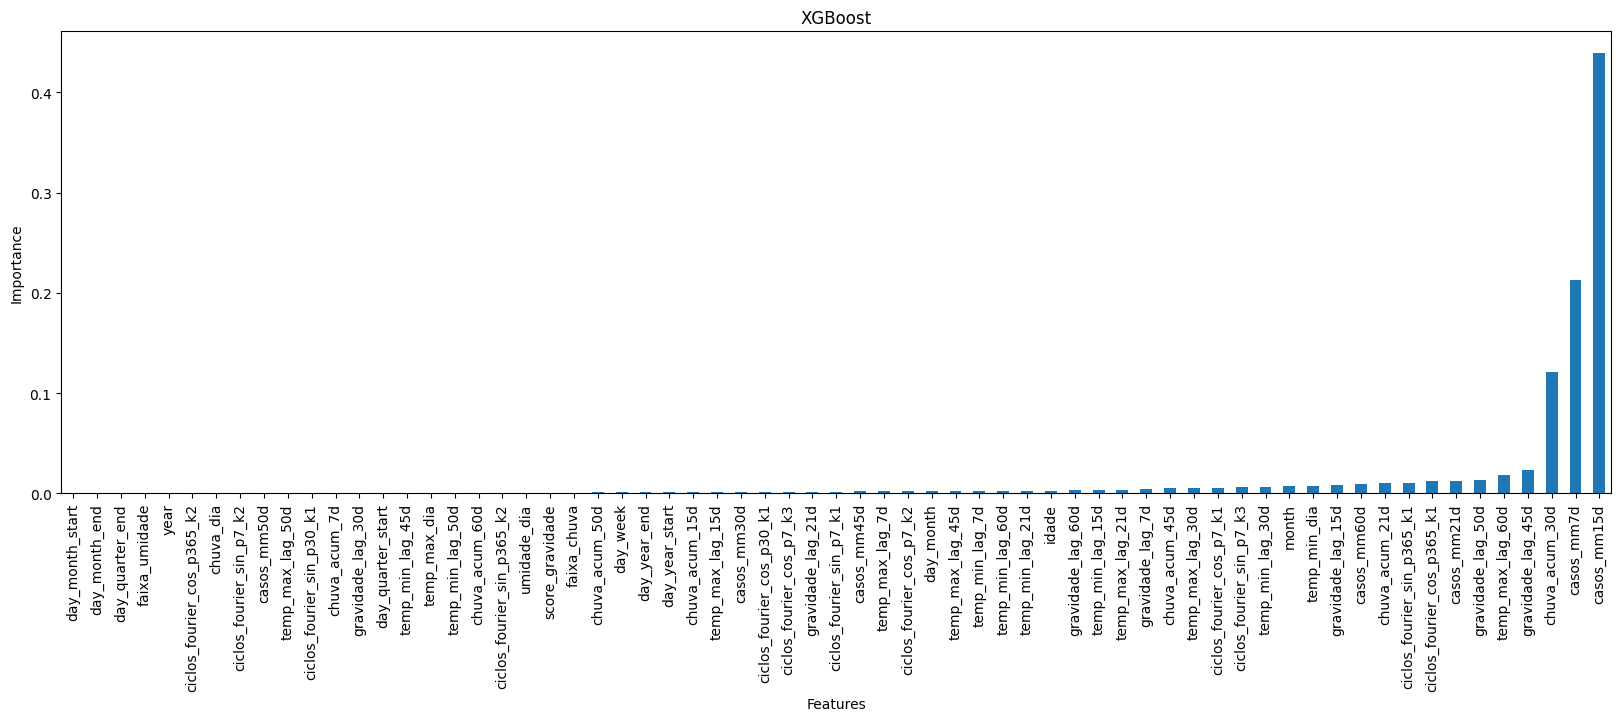

In [224]:
feat_selected_xg_boost.feature_importances_.plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title(label=f'{model_name}')
plt.show()

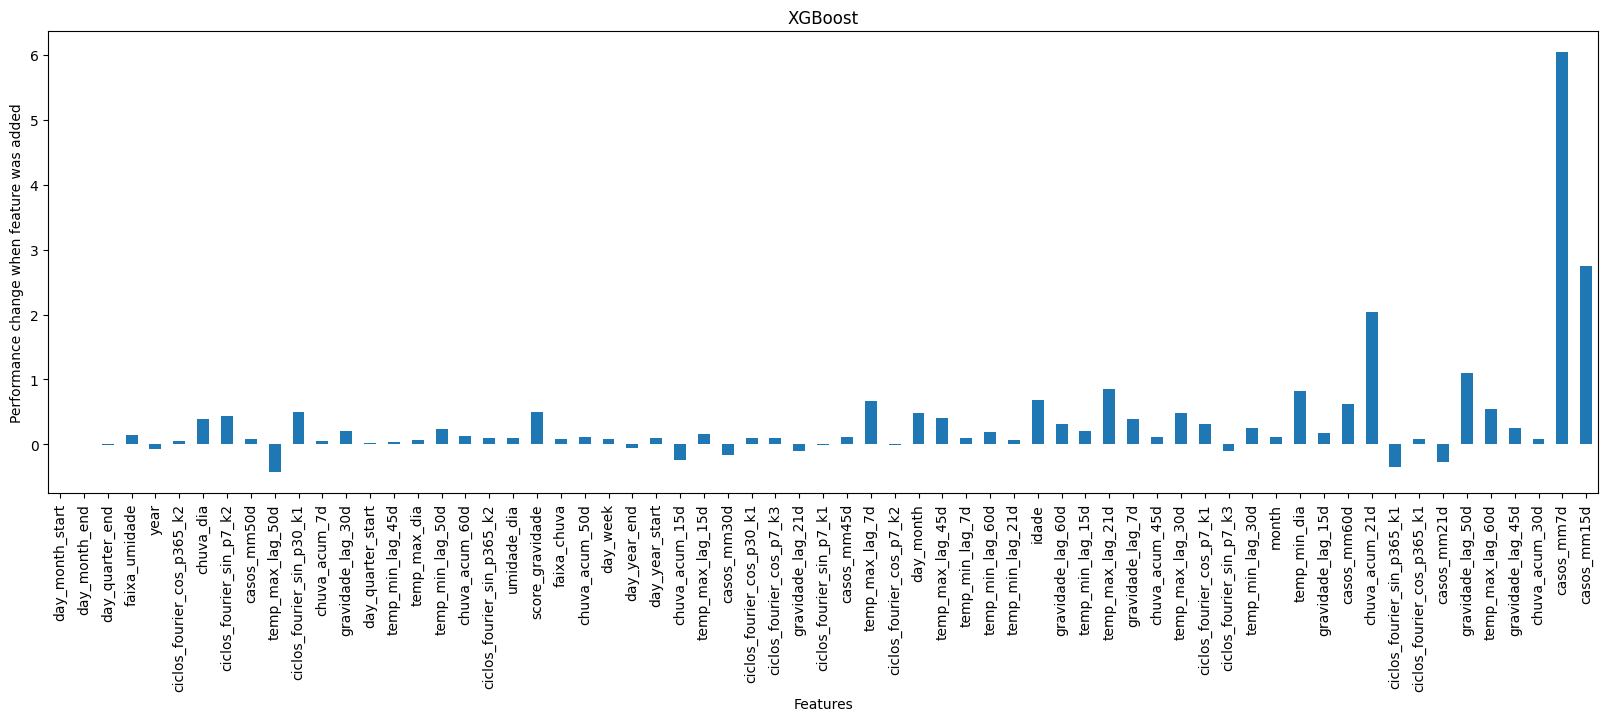

In [225]:
pd.Series(feat_selected_xg_boost.performance_drifts_).plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Performance change when feature was added')
plt.title(label=f'{model_name}')
plt.show()

In [226]:
# Extraindo as arrays de previsão do dicionário de retorno
y_pred_xg_boost = preds_prob_xg['y_pred']   # Mediana
y_lower_xg_boost = preds_prob_xg['y_lower'] # Limite Inferio
y_upper_xg_boost = preds_prob_xg['y_upper'] # Limite Superior

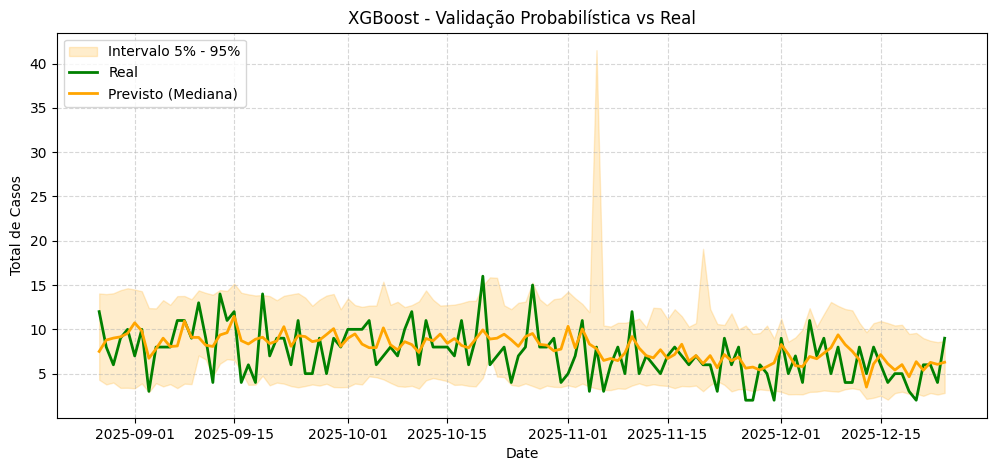

In [227]:
plt.figure(figsize=(12, 5))

plt.fill_between(
    y_val.index,
    y_lower_xg_boost,
    y_upper_xg_boost,
    color='orange',
    alpha=0.2,
    label=f'Intervalo {round(low_quantile * 100)}% - {round(high_quantile * 100)}%'
)

plt.plot(y_val.index, y_val, label='Real', color='green', lw=2)
plt.plot(y_val.index, y_pred_xg_boost, label='Previsto (Mediana)', color='orange', lw=2)

plt.title(f"{model_name} - Validação Probabilística vs Real")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [228]:
metrics_val = get_erros_metric_probabilistic(
    y_test=y_val,
    y_pred=y_pred_xg_boost,
    y_lower=y_lower_xg_boost,
    y_upper=y_upper_xg_boost,
    execution_time=(end_time - start_time),
    low_quantile=low_quantile,
    high_quantile=high_quantile
)
df_result = add_resultado(df_result, f'{model_name}_val', metrics_val)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Expected_Coverage,Real_Coverage,Mean_Pinball_Loss,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.9387,6.141543,2.478214,0.241681,0.9,0.8833,0.2737,4335.529105


In [229]:
# Copia os parâmetros salvos e força os quantis das pontas
params_low = best_params_xg_boost.copy()
params_high = best_params_xg_boost.copy()

In [230]:
params_low.update({"objective": "reg:quantileerror", "quantile_alpha": [low_quantile]})
params_high.update({"objective": "reg:quantileerror", "quantile_alpha": [high_quantile]})

In [231]:
# Instancia e treina as duas pontas usando os mesmos dados filtrados de treino
# (Certifique-se de aplicar o mesmo filtro de features no X_train se necessário)
X_train_selected = X_train_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)

model_lower = XGBRegressor(**params_low).fit(X_train_selected, y_train)
model_upper = XGBRegressor(**params_high).fit(X_train_selected, y_train)

In [232]:
X_test_selected = X_test_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)
X_test_selected.shape, X_test_selected.columns

((120, 51),
 Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
        'umidade_dia', 'month', 'day_week', 'chuva_acum_7d', 'gravidade_lag_7d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'chuva_acum_30d',
        'gravidade_lag_30d', 'chuva_acum_45d', 'gravidade_lag_45d',
        'chuva_acum_50d', 'gravidade_lag_50d', 'chuva_acum_60d',
        'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d', 'casos_mm45d',
        'casos_mm50d', 'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
        'day_month', 'day_quarter_start', 'day_year_start',
        'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k2',
        'ciclos_fourier_cos_p7_k3', 'ciclos_fourier_cos_p30_k1',
      

In [233]:
# Gera as predições das pontas + a sua linha que já estava pronta
start_time = time.time()
y_lower_final = model_lower.predict(X_test_selected)
y_upper_final = model_upper.predict(X_test_selected)
y_pred_final  = model_xg_boost.predict(X_test_selected) # A sua linha original
end_time = time.time()

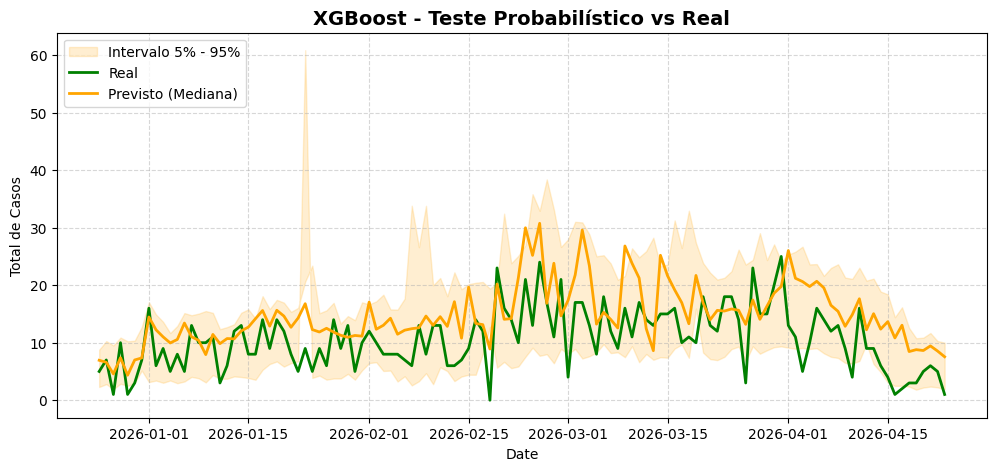

In [234]:
plt.figure(figsize=(12, 5))
plt.fill_between(y_test.index, y_lower_final, y_upper_final, color='orange', alpha=0.18, label=f'Intervalo {round(low_quantile * 100)}% - {round(high_quantile * 100)}%')
plt.plot(y_test.index, y_test, label='Real', color='green', lw=2)
plt.plot(y_test.index, y_pred_final, label='Previsto (Mediana)', color='orange', lw=2)

plt.title(f"{model_name} - Teste Probabilístico vs Real", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [235]:
metrics_test = get_erros_metric_probabilistic(
    y_test=y_test,
    y_pred=y_pred_final,
    y_lower=y_lower_final,
    y_upper=y_upper_final,
    execution_time=(end_time - start_time),
    low_quantile=low_quantile,
    high_quantile=high_quantile
)
df_result = add_resultado(df_result, f'{model_name}_test', metrics_test)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Expected_Coverage,Real_Coverage,Mean_Pinball_Loss,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.938700,6.141543,2.478214,0.241681,0.9,0.8833,0.2737,4335.529105
1,XGBoost_test,2025-12-25,2026-04-23,5.043803,38.887660,6.235997,-0.381567,0.9,0.8417,0.7577,0.025913


In [236]:
# Em séries temporais, como o seu projeto de dengue/saúde, após você validar tudo
# e chegar à conclusão de que o modelo é bom usando o `X_val`, existe um passo extra muito comum:

# **Retreinar o modelo com Treino + Validação:**
# Antes de fazer a predição final no Teste, muitos cientistas de dados juntam o Treino e
# a Validação em um único bloco e treinam o modelo uma última vez com esses dados combinados.
# Porque assim o modelo terá visto os dados mais recentes (da validação)
# antes de tentar prever o teste, o que é valioso para capturar as tendências mais próximas de 2026.

X_train_selected = X_train_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)
X_val_selected = X_val_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)


# Juntar treino e val para o último treino antes do teste real
X_final_train = pd.concat([X_train_selected, X_val_selected])
y_final_train = pd.concat([y_train, y_val])

# X_test_selected = X_test_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)

# model_xg_boost.fit(X_final_train, y_final_train)
# y_pred_final_agg = model_xg_boost.predict(X_test_selected) # Comparar com y_test

In [237]:
# Configurar os dicionários de parâmetros a partir dos melhores hiperparâmetros
params_median = best_params_xg_boost.copy()
params_low    = best_params_xg_boost.copy()
params_high   = best_params_xg_boost.copy()

In [238]:
# Injetar os objetivos quantílicos corretos em formato de lista para o XGBoost
params_median.update({"objective": "reg:quantileerror", "quantile_alpha": [0.50]})
params_low.update({"objective": "reg:quantileerror", "quantile_alpha": [low_quantile]})
params_high.update({"objective": "reg:quantileerror", "quantile_alpha": [high_quantile]})

In [239]:
# Instanciar os 3 modelos independentes para a base final
model_median_final = XGBRegressor(**params_median)
model_lower_final  = XGBRegressor(**params_low)
model_upper_final  = XGBRegressor(**params_high)

In [240]:
# Treinar os 3 modelos na base combinada (Treino + Validação)
start_time = time.time()

model_median_final.fit(X_final_train, y_final_train)
model_lower_final.fit(X_final_train, y_final_train)
model_upper_final.fit(X_final_train, y_final_train)

end_time = time.time()

In [241]:
# Filtrar as colunas da base de teste (caso não tenha rodado ainda)
# X_test_selected = X_test_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)

In [242]:
# Gerar as predições finais dos 3 horizontes para o Teste Real
y_pred_final_agg  = model_median_final.predict(X_test_selected)
y_lower_final_agg = model_lower_final.predict(X_test_selected)
y_upper_final_agg = model_upper_final.predict(X_test_selected)

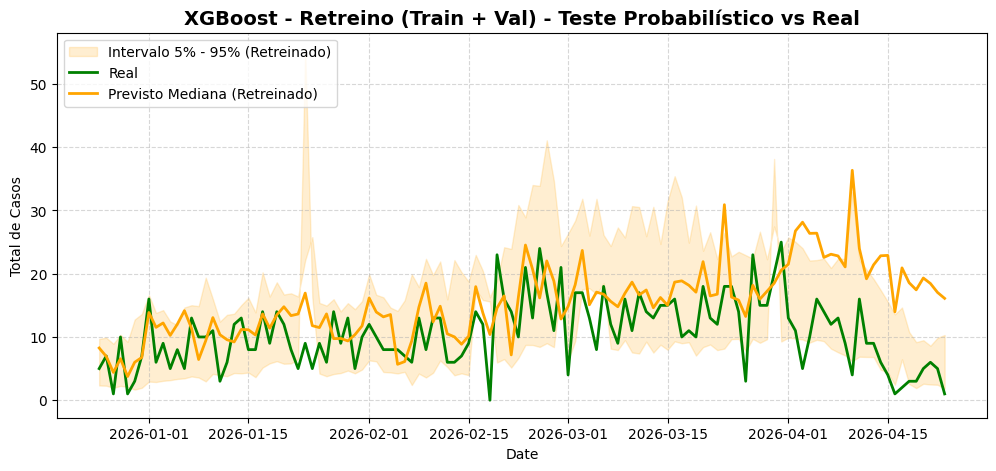

In [243]:
plt.figure(figsize=(12, 5))

plt.fill_between(
    y_test.index,
    y_lower_final_agg,
    y_upper_final_agg,
    color='orange',
    alpha=0.18,
    label=f'Intervalo {round(low_quantile * 100)}% - {round(high_quantile * 100)}% (Retreinado)'
)

plt.plot(y_test.index, y_test, label='Real', color='green', lw=2)

plt.plot(y_test.index, y_pred_final_agg, label='Previsto Mediana (Retreinado)', color='orange', lw=2)

plt.title(f"{model_name} - Retreino (Train + Val) - Teste Probabilístico vs Real", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [244]:
metrics_test_final = get_erros_metric_probabilistic(
    y_test=y_test,
    y_pred=y_pred_final_agg,
    y_lower=y_lower_final_agg,
    y_upper=y_upper_final_agg,
    execution_time=(end_time - start_time),
    low_quantile=low_quantile,
    high_quantile=high_quantile
)

# Adicionar à tabela geral de resultados
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_test_final)
display(df_result)

,Type,Start,End,MAE,MSE,RMSE,R2,Expected_Coverage,Real_Coverage,Mean_Pinball_Loss,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.938700,6.141543,2.478214,0.241681,0.9,0.8833,0.2737,4335.529105
1,XGBoost_test,2025-12-25,2026-04-23,5.043803,38.887660,6.235997,-0.381567,0.9,0.8417,0.7577,0.025913
2,XGBoost_test_agg,2025-12-25,2026-04-23,6.081363,65.538030,8.095556,-1.328378,0.9,0.7917,0.9319,7.057499


# LightGBM

In [245]:
start_time = time.time()
model_name = 'LightGBM'

y_pred_gbm, best_params_gbm, feat_selected_gbm, model_gbm, study = forecasting(
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val_scaled,
    model_name=model_name,
    n_trials=n_trials,
    n_splits=n_splits,
    random_state=SEED,
    prune=prune,
    n_startup_trials=n_startup_trials,
    n_warmup_steps=n_warmup_steps,
    early_stop=early_stop,
    low_quantile=low_quantile,
    high_quantile=high_quantile
)

end_time = time.time()

[I 2026-05-23 19:41:51,998] A new study created in memory with name: no-name-79b418a4-69f5-4e6c-a936-bf3c246aebc1
[I 2026-05-23 19:41:54,186] Trial 0 finished with value: 51.401061596011154 and parameters: {'n_estimators': 110, 'learning_rate': 0.015251622342171985, 'num_leaves': 131, 'max_depth': 8, 'min_child_samples': 100, 'subsample': 0.5068161181766915, 'colsample_bytree': 0.8244622297522939, 'reg_alpha': 4.394873674410141e-06, 'reg_lambda': 1.7461022545790173e-06}. Best is trial 0 with value: 51.401061596011154.
[I 2026-05-23 19:41:58,939] Trial 1 finished with value: 44.949462862731984 and parameters: {'n_estimators': 409, 'learning_rate': 0.02757701406720901, 'num_leaves': 116, 'max_depth': 3, 'min_child_samples': 69, 'subsample': 0.6372865785926256, 'colsample_bytree': 0.6510272575644519, 'reg_alpha': 0.04301437203974784, 'reg_lambda': 1.2534990969452515e-07}. Best is trial 1 with value: 44.949462862731984.
[I 2026-05-23 19:42:18,205] Trial 2 finished with value: 41.2110876885

In [246]:
# Histórico de Otimização (Vê se a métrica estabilizou)
# optuna.visualization.plot_optimization_history(study).show()
fig = optuna.visualization.plot_optimization_history(study)
img_name = 'optimization_history'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [247]:
# Importância dos Hiperparâmetros (O que realmente afetou o RMSE)
# optuna.visualization.plot_param_importances(study).show()
fig = optuna.visualization.plot_param_importances(study)
img_name = 'param_importances'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [248]:
# Gráfico de fatias (Slice Plot - mostra as regiões testadas para cada parâmetro)
# optuna.visualization.plot_slice(study).show()
fig = optuna.visualization.plot_slice(study)
img_name = 'slice'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [249]:
# Coordenadas Paralelas (Visualiza a relação entre todos os parâmetros e o resultado)
# optuna.visualization.plot_parallel_coordinate(study).show()
fig = optuna.visualization.plot_parallel_coordinate(study)
img_name = 'parallel_coordinate'
save_img(fig, img_name, nt, model_name, n_trials)
fig.show()

In [250]:
print(f'{model_name}: {best_params_gbm}')

LightGBM: {'n_estimators': 638, 'learning_rate': 0.005147368483475453, 'num_leaves': 145, 'max_depth': 5, 'min_child_samples': 5, 'subsample': 0.5806965265775406, 'colsample_bytree': 0.8732124753104546, 'reg_alpha': 1.125193215456675e-06, 'reg_lambda': 1.951042967639678e-08}


In [251]:
feat_selected_gbm.initial_model_performance_

np.float64(-64.98967986896976)

In [252]:
len(feat_selected_gbm.features_to_drop_)

21

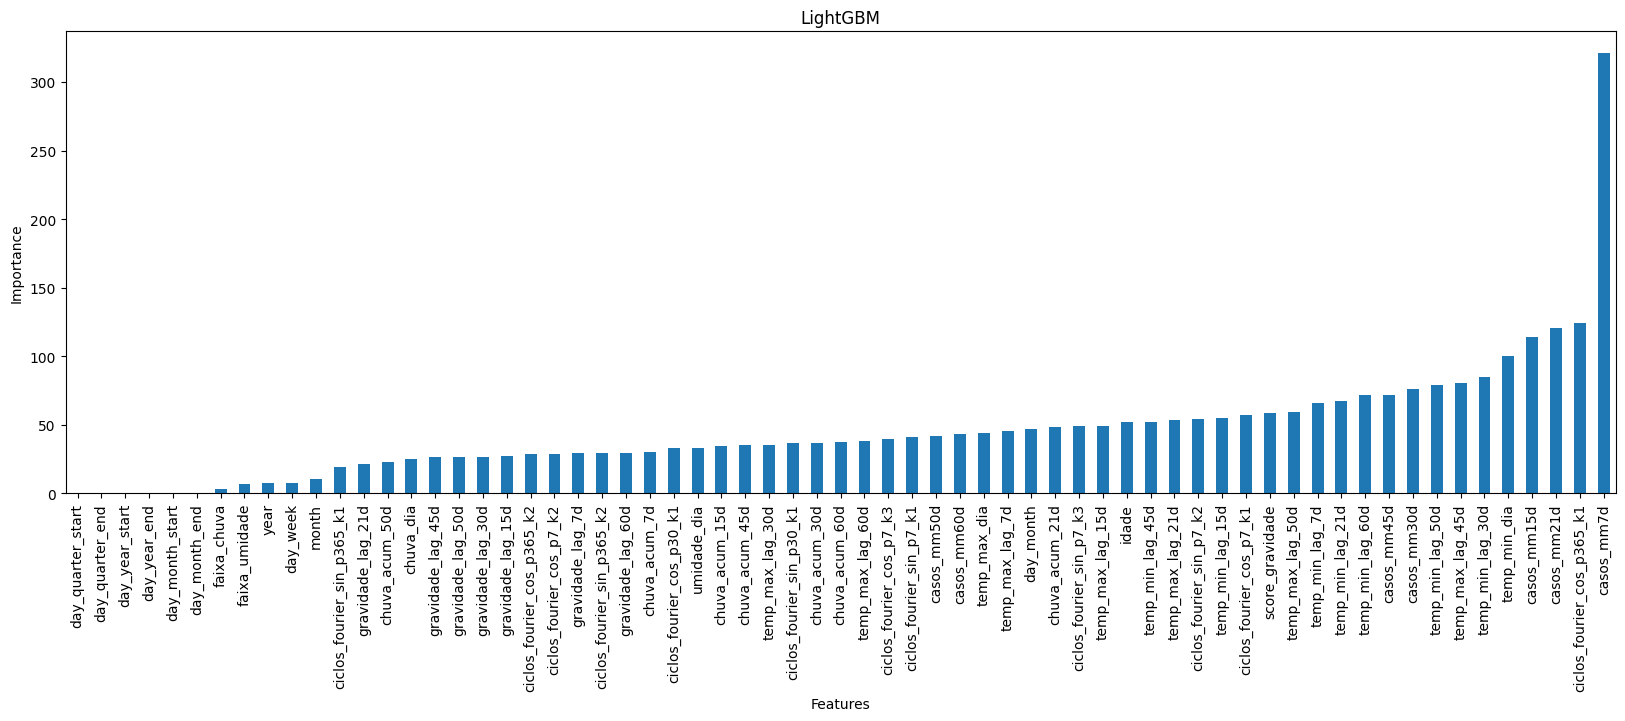

In [253]:
feat_selected_gbm.feature_importances_.plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title(label=f'{model_name}')
plt.show()

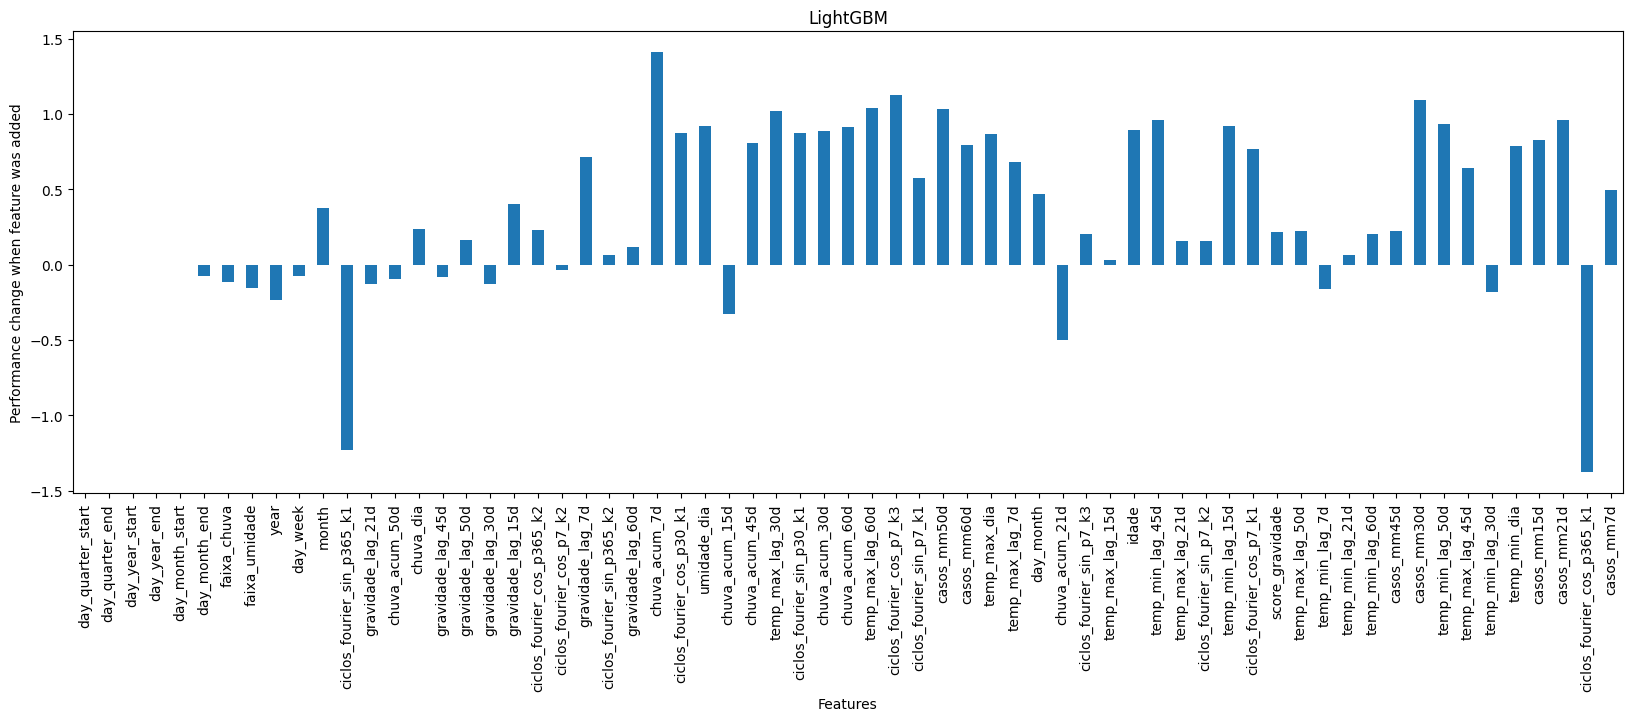

In [254]:
pd.Series(feat_selected_gbm.performance_drifts_).plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Performance change when feature was added')
plt.title(label=f'{model_name}')
plt.show()

In [255]:
# Extraindo as arrays de previsão do dicionário de retorno do LightGBM
y_pred_gbm_val = y_pred_gbm['y_pred']   # Mediana
y_lower_gbm_val = y_pred_gbm['y_lower'] # Limite Inferior
y_upper_gbm_val = y_pred_gbm['y_upper'] # Limite Superior

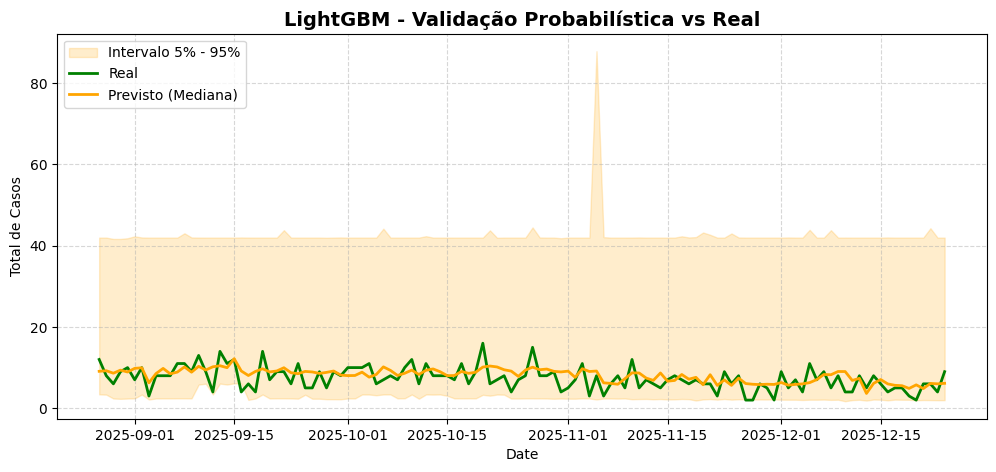

In [256]:
plt.figure(figsize=(12, 5))
plt.fill_between(y_val.index, y_lower_gbm_val, y_upper_gbm_val, color='orange', alpha=0.2, label=f'Intervalo {round(low_quantile * 100)}% - {round(high_quantile * 100)}%')
plt.plot(y_val.index, y_val, label='Real', color='green', lw=2)
plt.plot(y_val.index, y_pred_gbm_val, label='Previsto (Mediana)', color='orange', lw=2)

plt.title(f"{model_name} - Validação Probabilística vs Real", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [257]:
metrics_gbm_val = get_erros_metric_probabilistic(
    y_test=y_val,
    y_pred=y_pred_gbm_val,
    y_lower=y_lower_gbm_val,
    y_upper=y_upper_gbm_val,
    execution_time=(end_time - start_time),
    low_quantile=low_quantile,
    high_quantile=high_quantile
)
df_result = add_resultado(df_result, f'{model_name}_val', metrics_gbm_val)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Expected_Coverage,Real_Coverage,Mean_Pinball_Loss,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.938700,6.141543,2.478214,0.241681,0.9,0.8833,0.2737,4335.529105
1,XGBoost_test,2025-12-25,2026-04-23,5.043803,38.887660,6.235997,-0.381567,0.9,0.8417,0.7577,0.025913
2,XGBoost_test_agg,2025-12-25,2026-04-23,6.081363,65.538030,8.095556,-1.328378,0.9,0.7917,0.9319,7.057499
3,LightGBM_val,2025-08-27,2025-12-24,2.015747,6.429554,2.535656,0.206119,0.9,0.9667,1.0086,1085.208489


In [258]:
# Copia os parâmetros salvos e força os quantis das pontas
params_low = best_params_gbm.copy()
params_high = best_params_gbm.copy()

In [259]:
params_low.update({"objective": "quantile", "alpha": [low_quantile]})
params_high.update({"objective": "quantile", "alpha": [high_quantile]})

In [260]:
# Instancia e treina as duas pontas usando os mesmos dados filtrados de treino
# (Certifique-se de aplicar o mesmo filtro de features no X_train se necessário)
X_train_selected = X_train_scaled.drop(columns=feat_selected_gbm.features_to_drop_)

In [261]:
model_lower = LGBMRegressor(**params_low).fit(X_train_selected, y_train)
model_upper = LGBMRegressor(**params_high).fit(X_train_selected, y_train)

In [262]:
X_test_selected = X_test_scaled.drop(columns=feat_selected_gbm.features_to_drop_)
X_test_selected.shape, X_test_selected.columns

((120, 44),
 Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
        'umidade_dia', 'month', 'chuva_acum_7d', 'gravidade_lag_7d',
        'gravidade_lag_15d', 'chuva_acum_30d', 'chuva_acum_45d',
        'gravidade_lag_50d', 'chuva_acum_60d', 'gravidade_lag_60d',
        'casos_mm7d', 'casos_mm15d', 'casos_mm21d', 'casos_mm30d',
        'casos_mm45d', 'casos_mm50d', 'casos_mm60d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_45d', 'temp_min_lag_50d',
        'temp_min_lag_60d', 'temp_max_lag_7d', 'temp_max_lag_15d',
        'temp_max_lag_21d', 'temp_max_lag_30d', 'temp_max_lag_45d',
        'temp_max_lag_50d', 'temp_max_lag_60d', 'day_month',
        'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k1',
        'ciclos_fourier_sin_p7_k2', 'ciclos_fourier_cos_p7_k3',
        'ciclos_fourier_sin_p7_k3', 'ciclos_fourier_cos_p30_k1',
        'ciclos_fourier_sin_p30_k1', 'ciclos_fourier_cos_p365_k2',
        'ciclos_fourier_sin_p365_k2'],
  

In [263]:
# Gera as predições das pontas + a sua linha que já estava pronta
start_time = time.time()
y_lower_final = model_lower.predict(X_test_selected)
y_upper_final = model_upper.predict(X_test_selected)
y_pred_final  = model_gbm.predict(X_test_selected)
end_time = time.time()

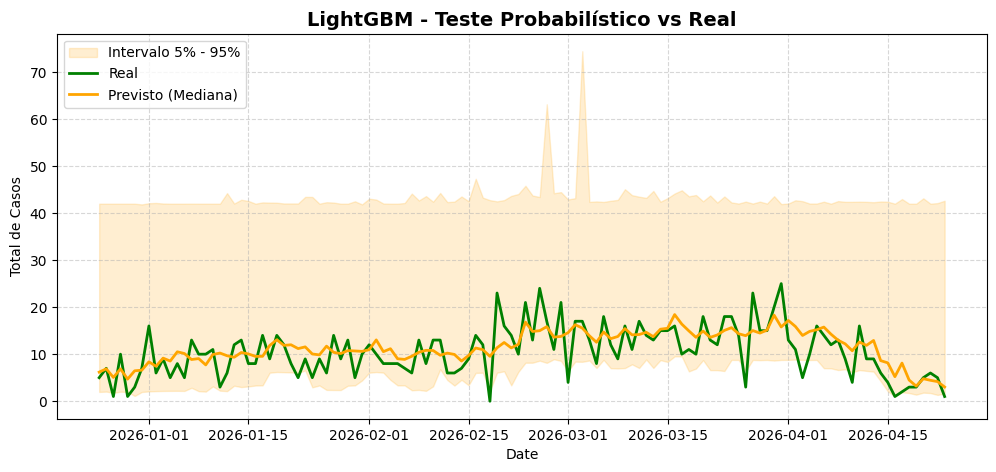

In [264]:
plt.figure(figsize=(12, 5))
plt.fill_between(y_test.index, y_lower_final, y_upper_final, color='orange', alpha=0.18, label=f'Intervalo {round(low_quantile * 100)}% - {round(high_quantile * 100)}%')
plt.plot(y_test.index, y_test, label='Real', color='green', lw=2)
plt.plot(y_test.index, y_pred_final, label='Previsto (Mediana)', color='orange', lw=2)

plt.title(f"{model_name} - Teste Probabilístico vs Real", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [265]:
metrics_test = get_erros_metric_probabilistic(
    y_test=y_test,
    y_pred=y_pred_final,
    y_lower=y_lower_final,
    y_upper=y_upper_final,
    execution_time=(end_time - start_time),
    low_quantile=low_quantile,
    high_quantile=high_quantile
)
df_result = add_resultado(df_result, f'{model_name}_test', metrics_test)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Expected_Coverage,Real_Coverage,Mean_Pinball_Loss,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.938700,6.141543,2.478214,0.241681,0.9,0.8833,0.2737,4335.529105
1,XGBoost_test,2025-12-25,2026-04-23,5.043803,38.887660,6.235997,-0.381567,0.9,0.8417,0.7577,0.025913
2,XGBoost_test_agg,2025-12-25,2026-04-23,6.081363,65.538030,8.095556,-1.328378,0.9,0.7917,0.9319,7.057499
3,LightGBM_val,2025-08-27,2025-12-24,2.015747,6.429554,2.535656,0.206119,0.9,0.9667,1.0086,1085.208489
4,LightGBM_test,2025-12-25,2026-04-23,3.109478,15.836285,3.979483,0.437382,0.9,0.9250,1.0196,0.016818


In [266]:
X_train_selected = X_train_scaled.drop(columns=feat_selected_gbm.features_to_drop_)
X_val_selected = X_val_scaled.drop(columns=feat_selected_gbm.features_to_drop_)

In [267]:
# Juntar treino e val para o último treino antes do teste real
X_final_train = pd.concat([X_train_selected, X_val_selected])
y_final_train = pd.concat([y_train, y_val])

In [268]:
# Configurar os dicionários de parâmetros a partir dos melhores hiperparâmetros
params_median = best_params_gbm.copy()
params_low    = best_params_gbm.copy()
params_high   = best_params_gbm.copy()

In [269]:
# Injetar os objetivos quantílicos corretos em formato de lista
params_median.update({"objective": "quantile", "alpha": [0.50]})
params_low.update({"objective": "quantile", "alpha": [low_quantile]})
params_high.update({"objective": "quantile", "alpha": [high_quantile]})

In [270]:
# Instanciar os 3 modelos independentes para a base final
model_median_final = LGBMRegressor(**params_median)
model_lower_final  = LGBMRegressor(**params_low)
model_upper_final  = LGBMRegressor(**params_high)

In [271]:
# Treinar os 3 modelos na base combinada (Treino + Validação)
start_time = time.time()

model_median_final.fit(X_final_train, y_final_train)
model_lower_final.fit(X_final_train, y_final_train)
model_upper_final.fit(X_final_train, y_final_train)

end_time = time.time()

In [272]:
# Gerar as predições finais dos 3 horizontes para o Teste Real
y_pred_final_agg  = model_median_final.predict(X_test_selected)
y_lower_final_agg = model_lower_final.predict(X_test_selected)
y_upper_final_agg = model_upper_final.predict(X_test_selected)

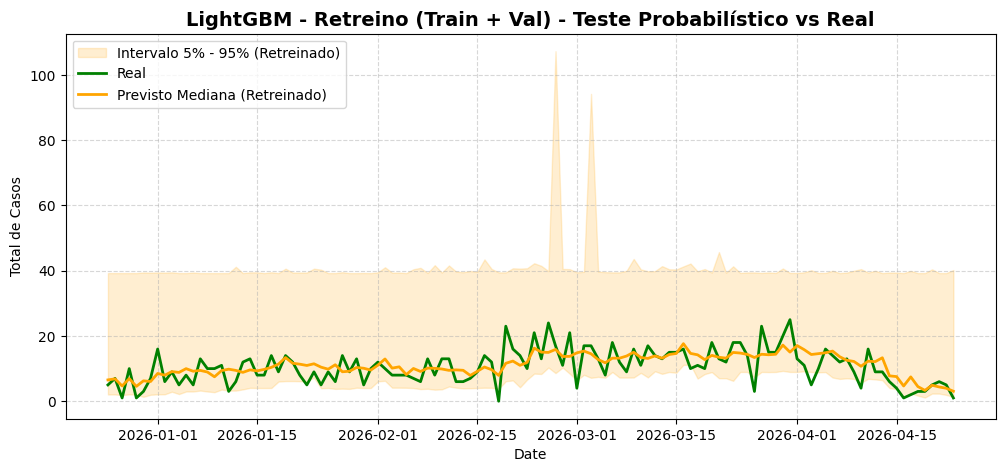

In [273]:
plt.figure(figsize=(12, 5))

plt.fill_between(
    y_test.index,
    y_lower_final_agg,
    y_upper_final_agg,
    color='orange',
    alpha=0.18,
    label=f'Intervalo {round(low_quantile * 100)}% - {round(high_quantile * 100)}% (Retreinado)'
)

plt.plot(y_test.index, y_test, label='Real', color='green', lw=2)

plt.plot(y_test.index, y_pred_final_agg, label='Previsto Mediana (Retreinado)', color='orange', lw=2)

plt.title(f"{model_name} - Retreino (Train + Val) - Teste Probabilístico vs Real", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [274]:
metrics_test_final = get_erros_metric_probabilistic(
    y_test=y_test,
    y_pred=y_pred_final_agg,
    y_lower=y_lower_final_agg,
    y_upper=y_upper_final_agg,
    execution_time=(end_time - start_time),
    low_quantile=low_quantile,
    high_quantile=high_quantile
)

# Adicionar à tabela geral de resultados
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_test_final)
display(df_result)

,Type,Start,End,MAE,MSE,RMSE,R2,Expected_Coverage,Real_Coverage,Mean_Pinball_Loss,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.938700,6.141543,2.478214,0.241681,0.9,0.8833,0.2737,4335.529105
1,XGBoost_test,2025-12-25,2026-04-23,5.043803,38.887660,6.235997,-0.381567,0.9,0.8417,0.7577,0.025913
2,XGBoost_test_agg,2025-12-25,2026-04-23,6.081363,65.538030,8.095556,-1.328378,0.9,0.7917,0.9319,7.057499
3,LightGBM_val,2025-08-27,2025-12-24,2.015747,6.429554,2.535656,0.206119,0.9,0.9667,1.0086,1085.208489
4,LightGBM_test,2025-12-25,2026-04-23,3.109478,15.836285,3.979483,0.437382,0.9,0.9250,1.0196,0.016818
5,LightGBM_test_agg,2025-12-25,2026-04-23,3.072760,15.388830,3.922860,0.453279,0.9,0.9000,0.9734,7.249599
